# Proyecto Integrador: 
# Sistema Inteligente para Detección de Fatiga mediante Visión Artificial e Inteligencia Artificial

Este proyecto desarrolla un sistema capaz de detectar estados como cansancio, distracción, concentración y estado normal mediante procesamiento de imágenes faciales y técnicas de aprendizaje automático.

El sistema utiliza métricas faciales como:

- EAR (Eye Aspect Ratio)
- MAR (Mouth Aspect Ratio)
- PERCLOS
- Parpadeos
- Cabeceos
- Microsueños

Los datos obtenidos son utilizados para entrenar un modelo de inteligencia artificial capaz de realizar predicciones en tiempo real.

# Instalacion de librerias

En esta sección se instalan las librerias necesarias para el desarrollo del proyecto.

Las principales librerias utilizadas son:

- Pandas: para el manejo y organización de los datos.
- Matplootlib: visualizar datos.
- Scikit-learn: entrenamiento y evaluación del modelo.

In [1]:
import sys
!{sys.executable} -m pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Se importan las librerias necesarias para realizar el procesamiento de datos, cálculos numéricos y visualización de resultados.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carga del conjunto de datos

En esta sección se carga el archivo CSV generado durante el proceso de captura de datos.

El conjunto de datos contiene informacion obtenida mediante visión artificial como:

- EAR
- MAR
- Estado de la cabeza
- Parpadeos
- Microsueños
- Cabeceos
- PERCLOS

Estos datos se utilizan porsteriormente para entrenar al modelo de inteligencia artificial.

In [4]:
ruta_csv = "../datos/datos_fatiga.csv"

df = pd.read_csv(ruta_csv)
df.head()

,fecha_hora,id_sesion,tipo_sesion,ear,mar,estado_cabeza,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos
0,2026-05-07 18:15:58.076,20260507_181554,normal,0.3049,0.0000,frente,0,0,0,0,0,0,0,0.0
1,2026-05-07 18:15:58.604,20260507_181554,normal,0.2926,0.0000,frente,0,0,0,0,0,0,0,0.0
2,2026-05-07 18:15:59.148,20260507_181554,normal,0.2929,0.0000,frente,0,0,0,0,0,0,0,0.0
3,2026-05-07 18:15:59.651,20260507_181554,normal,0.2920,0.0000,frente,0,0,0,0,0,0,0,0.0
4,2026-05-07 18:16:00.172,20260507_181554,normal,0.3041,0.0182,frente,0,0,0,0,0,0,0,0.0


# Dimensiones del conjunto de datos.

En esta sección se analiza el tamño del conjunto de datos a identificar:

- **Número de registrsos.** "Filas o muestras"
- **Número de variable disponibles.** "Columnas o variables registradas"

Esto permite tener nocion del numero de datos que vamos a manejar.

In [5]:
df.shape

(17825, 14)

# Información general del conjunto de datos

En esta sección se revisa la estructura general del conjunto de datos para identificar:

- **Tipos de variables**
- **Cantidad de registros**
- **Valores faltantes**
- **Consistencia de datos**

Esto permite verificar que los datos sean adecuados antes del entrenamiento.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17825 entries, 0 to 17824
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fecha_hora              17825 non-null  object 
 1   id_sesion               17825 non-null  object 
 2   tipo_sesion             17825 non-null  object 
 3   ear                     17825 non-null  float64
 4   mar                     17825 non-null  float64
 5   estado_cabeza           17825 non-null  object 
 6   mirando_abajo           17825 non-null  int64  
 7   parpadeos_total         17825 non-null  int64  
 8   parpadeos_por_minuto    17825 non-null  int64  
 9   cabeceos_total          17825 non-null  int64  
 10  cabeza_abajo_sostenida  17825 non-null  int64  
 11  bostezos                17825 non-null  int64  
 12  microsuenos             17825 non-null  int64  
 13  perclos                 17825 non-null  float64
dtypes: float64(3), int64(7), object(4)
mem

# Estadísticas descriptivas

En esta sección se calculan estadísticas generales para las variables numéricas:

- **Media**
- **Desviación estándar**
- **Valores mínimos**
- **Valores máximos**
- **Percentiles**

Esto permite comprender el comportamiento general de los datos obtenidos.

In [7]:
df.describe()

,ear,mar,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos
count,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000,17825.000000
mean,0.277862,0.016371,0.081907,43.003927,5.680449,1.146143,0.065077,1.526957,11.863001,0.107706
std,0.041283,0.071583,0.274231,44.937913,5.589446,2.230620,0.246669,3.993889,19.451857,0.219364
min,0.088800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.252000,0.000000,0.000000,10.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.277400,0.000000,0.000000,25.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.006700
75%,0.309000,0.014000,0.000000,61.000000,8.000000,2.000000,0.000000,0.000000,14.000000,0.080000
max,0.515200,1.030500,1.000000,201.000000,43.000000,18.000000,1.000000,14.000000,77.000000,1.000000


# Distribución de clases

En esta sección se analiza la cantidad de muestras registradas para cada categoría:

- **Normal**
- **Cansado**
- **Distraído**
- **Concentrado**

Esto permite identificar posibles desbalances entre clases antes del entrenamiento.

In [8]:
df["tipo_sesion"].value_counts()

tipo_sesion
concentrado    7406
distraido      5067
cansado        2965
normal         2387
Name: count, dtype: int64

# Conversión de variables a tasas por minuto

En esta sección se transforman algunas variables acumulativas a valores expresados por minuto.

Las variables convertidas son:

- **Cabeceos por minuto**
- **Bostezos por minuto**
- **Microsueños por minuto**

Esta transformación permite representar mejor la frecuencia real de eventos ocurridos durante cada sesión y evita que el modelo dependa únicamente del tiempo de duración de captura.

En la parte de df["segundos"], Tiempo actual − Tiempo inicial

In [9]:
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

df = df.sort_values(["id_sesion", "fecha_hora"]).reset_index(drop=True)

df["segundos"] = df.groupby("id_sesion")["fecha_hora"].transform(
    lambda x: (x - x.min()).dt.total_seconds()
)

minutos = np.maximum(df["segundos"], 30) / 60.0

df["cabeceos_por_minuto"] = df["cabeceos_total"] / minutos
df["bostezos_por_minuto"] = df["bostezos"] / minutos
df["microsuenos_por_minuto"] = df["microsuenos"] / minutos

df.head()

,fecha_hora,id_sesion,tipo_sesion,ear,mar,estado_cabeza,mirando_abajo,parpadeos_total,parpadeos_por_minuto,cabeceos_total,cabeza_abajo_sostenida,bostezos,microsuenos,perclos,segundos,cabeceos_por_minuto,bostezos_por_minuto,microsuenos_por_minuto
0,2026-05-07 18:15:58.076,20260507_181554,normal,0.3049,0.0000,frente,0,0,0,0,0,0,0,0.0,0.000,0.0,0.0,0.0
1,2026-05-07 18:15:58.604,20260507_181554,normal,0.2926,0.0000,frente,0,0,0,0,0,0,0,0.0,0.528,0.0,0.0,0.0
2,2026-05-07 18:15:59.148,20260507_181554,normal,0.2929,0.0000,frente,0,0,0,0,0,0,0,0.0,1.072,0.0,0.0,0.0
3,2026-05-07 18:15:59.651,20260507_181554,normal,0.2920,0.0000,frente,0,0,0,0,0,0,0,0.0,1.575,0.0,0.0,0.0
4,2026-05-07 18:16:00.172,20260507_181554,normal,0.3041,0.0182,frente,0,0,0,0,0,0,0,0.0,2.096,0.0,0.0,0.0


### Interpretación

Se transformaron variables acumulativas a tasas por minuto para representar de forma más adecuada la frecuencia de eventos registrados durante cada sesión.

Esta transformación evita que el modelo dependa únicamente de la duración total de captura y mejora la capacidad de clasificación entre estados similares.

# Selección de variables para el modelo

En esta sección se seleccionan las variables que serán utilizadas como entradas para el entrenamiento del modelo de Inteligencia Artificial.

Las variables seleccionadas corresponden a características faciales y eventos detectados durante el proceso de adquisición de datos.

Variables utilizadas:

- **EAR**
- **MAR**
- **Mirando abajo**
- **Parpadeos por minuto**
- **PERCLOS**
- **Cabeceos por minuto**
- **Bostezos por minuto**
- **Microsueños por minuto**

Estas variables serán utilizadas para predecir el estado del usuario.

x: caracteristica
y: respuesta correcta

In [10]:
features = [
    "ear",
    "mar",
    "mirando_abajo",
    "parpadeos_por_minuto",
    "perclos",
    "cabeceos_por_minuto",
    "bostezos_por_minuto",
    "microsuenos_por_minuto",
]

X = df[features].fillna(0)
y = df["tipo_sesion"]

### Interpretación

Se seleccionaron únicamente las variables relevantes para el entrenamiento del modelo.

Las variables relacionadas con características faciales y eventos detectados permiten proporcionar información suficiente para diferenciar estados como cansancio, distracción, concentración y estado normal.

Las variables de identificación como fecha o identificador de sesión fueron excluidas debido a que no aportan información útil durante la clasificación.

# División del conjunto de datos y entrenamiento del modelo

En esta sección se divide el conjunto de datos en dos partes:

- **Datos de entrenamiento**
- **Datos de prueba**

La división permite entrenar el modelo con una parte de los datos y posteriormente evaluar su desempeño utilizando información que el modelo no ha visto anteriormente.

Posteriormente se implementa un modelo **Random Forest**, el cual utiliza múltiples árboles de decisión para realizar la clasificación.

Este modelo fue seleccionado debido a:

- **Buena capacidad de clasificación**
- **Menor riesgo de sobreajuste**
- **Buen desempeño con múltiples variables**
- **Capacidad para manejar datos complejos**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,                                        # 20% para pruebas
    random_state = 42,                                      # Fija una semilla aleatoria
    stratify = y                                            # Hace proporciones similares
)

modelo = RandomForestClassifier(
    n_estimators=500,                                       # Numero de arboles a crear
    max_depth = 15,                                         # Pequeño aprende poco, grande memoriza
    min_samples_split = 10,                                 # Divisiones apra muestras, evitar sobreajuste
    class_weight = "balanced",                              # Compensa el desbalance del numero de datos tomados
    random_state = 42,
    n_jobs = -1                                             # Procesadores a usar
)

modelo.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Interpretación

El conjunto de datos fue dividido en entrenamiento y prueba para evaluar el desempeño del modelo con datos no vistos previamente.

Se utilizó un modelo **Random Forest**, configurado con múltiples árboles de decisión y técnicas de balanceo entre clases para mejorar la capacidad de clasificación y reducir problemas de sobreajuste.

# Evaluación del modelo

En esta sección se evalúa el desempeño del modelo entrenado utilizando datos que no fueron observados durante el proceso de aprendizaje.

Las métricas utilizadas son:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **Matriz de confusión**

Estas métricas permiten analizar la capacidad del modelo para clasificar correctamente los diferentes estados detectados.

In [12]:
from sklearn.metrics import classification_report               # Libreria para generar informes del modelo

predicciones = modelo.predict(X_test)                           # Predicciones

print(classification_report(y_test, predicciones))              # Compara respuesta real vs respuesta predicha

              precision    recall  f1-score   support

     cansado       0.99      0.97      0.98       593
 concentrado       0.96      0.95      0.96      1481
   distraido       1.00      0.98      0.99      1014
      normal       0.86      0.94      0.90       477

    accuracy                           0.96      3565
   macro avg       0.95      0.96      0.96      3565
weighted avg       0.96      0.96      0.96      3565



# Matriz de confusión

La matriz de confusión permite visualizar las clases correctamente identificadas y los errores generados por el modelo durante la clasificación.

La diagonal principal representa las predicciones correctas, mientras que los valores fuera de la diagonal indican errores de clasificación.

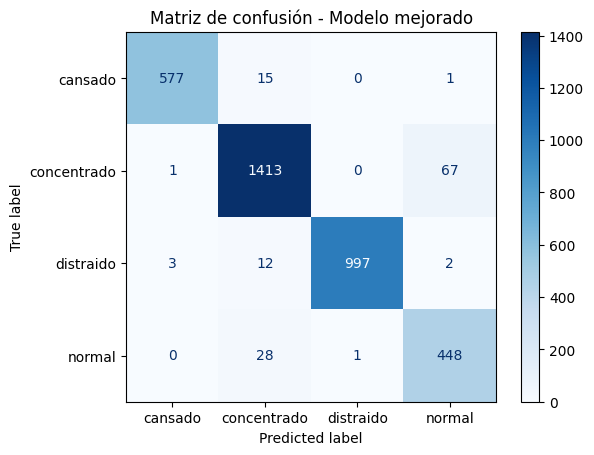

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay               # Importa la herramienta para dibujar la matriz
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(                           # Predicho contra real
    modelo,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Matriz de confusión - Modelo mejorado")
plt.show()

### Interpretación

La matriz de confusión muestra que la mayoría de los registros fueron clasificados correctamente, observándose valores elevados en la diagonal principal.

Los errores observados se presentan principalmente entre clases con características similares, como estados de concentración y normalidad.

# Importancia de variables

En esta sección se analiza el nivel de influencia que tuvo cada variable durante el entrenamiento del modelo.

La importancia indica qué tan relevante fue una característica para ayudar al modelo a diferenciar los distintos estados detectados.

Valores mayores representan una mayor contribución durante la clasificación.

Se ordena del mas importante al menos importante comenzando desde la parte superior.

In [14]:
importancias = pd.DataFrame({
    "variable": features,
    "importancia": modelo.feature_importances_
}).sort_values("importancia", ascending=False)

importancias

,variable,importancia
7,microsuenos_por_minuto,0.267605
5,cabeceos_por_minuto,0.212331
0,ear,0.171043
6,bostezos_por_minuto,0.148563
4,perclos,0.061343
3,parpadeos_por_minuto,0.057309
2,mirando_abajo,0.051284
1,mar,0.030523


### Interpretación

Se observa que las variables relacionadas con **microsueños**, **cabeceos** y **EAR** presentan una mayor importancia durante el entrenamiento.

Esto indica que dichas características tuvieron una mayor influencia para diferenciar los estados del usuario.

Las variables con menor importancia continúan aportando información, aunque su contribución durante la clasificación fue menor.

# Almacenamiento del modelo entrenado

Una vez finalizado el entrenamiento, el modelo generado se almacena para poder reutilizarlo posteriormente durante el proceso de predicción en tiempo real.

También se guardan las variables utilizadas durante el entrenamiento para mantener la consistencia entre el modelo y los nuevos datos.

In [ ]:
import os                                                       # Maneja carpetas y rutas
import joblib                                                   # Guarda y carga modelos IA

os.makedirs("../modelos", exist_ok=True)

joblib.dump(modelo, "../modelos/modelo_fatiga.pkl")
joblib.dump(features, "../modelos/columnas.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente
